# 10 -- A Learned CrowdRL Policy as a JuPedSim Operational Model

This notebook recreates the flow of JuPedSim's
[getting started guide](https://www.jupedsim.org/stable/notebooks/getting_started.html),
with one substitution: instead of a built-in operational model (e.g. the
Collision Free Speed Model), the agents are driven by a **trained CrowdRL
policy** deployed through `crowdrl_jupedsim.LearnedPolicyModel`.

The policy artefact is the repo's `example_model/policy_r0400.onnx` -- a
**self-describing** ONNX (issue #7): its resolved observation/action configs
and provenance are embedded in the file's metadata, so the adapter needs no
hand-supplied configuration at all.

Scenarios (the same two the e2e test `tests/test_e2e_jupedsim_trained_policy.py`
pins):

1. **Corner** -- the L-corridor from
   [jupedsim#1625](https://github.com/PedestrianDynamics/jupedsim/issues/1625):
   agents must follow the routed waypoint around a bend they cannot see the
   goal through.
2. **Bottleneck** -- 12 agents through a 1.4 m aperture: crowd behaviour,
   not just solo navigation.

Requirements: a JuPedSim 2.0 source build on `sys.path` (the custom-model
layer is not on PyPI -- see `plan/handover_2026-07-29.md` for the local
wiring) plus the `dev` extra (`pedpy`, `plotly`) for the animation.

In [1]:
from pathlib import Path
import sys

# JuPedSim 2.0 comes from a local source build. If a plain import fails,
# fall back to the known local build paths (machine-specific wiring).
try:
    import jupedsim as jps
except ImportError:
    _JPS = Path("/home/fabi/dev/jupedsim")
    sys.path[:0] = [
        str(_JPS / "python_modules" / "jupedsim"),
        str(_JPS / "build-py312" / "lib"),
    ]
    import jupedsim as jps

import shapely
import plotly.io as pio
from jupedsim.internal.notebook_utils import animate, read_sqlite_file

from crowdrl_jupedsim import CrowdRLAgentState, LearnedPolicyModel, OnnxPolicy

# notebook_utils pins the renderer for the jupedsim.org docs build; the plain
# mimetype renderer keeps outputs small and renders in VS Code / JupyterLab.
pio.renderers.default = "plotly_mimetype"

print("jupedsim", jps.__version__)

jupedsim 2.0.0


## The self-describing policy

`OnnxPolicy` reads the training configuration back out of the artefact.
Nothing below is typed in by hand -- and if we *did* pass an explicit config
that disagrees with the embedded record, construction would raise.

In [2]:
POLICY_PATH = Path("..") / "example_model" / "policy_r0400.onnx"

policy = OnnxPolicy(POLICY_PATH)
meta = policy.metadata
print("obs_dim:", meta.obs_dim, "| action_dim:", meta.action_dim)
print("provenance:", meta.provenance)
print(
    "use_goal_direction =", meta.obs_config.use_goal_direction,
    "-> the policy navigates by the routed next waypoint alone",
)

obs_dim: 89 | action_dim: 4
provenance: {'run': 'results_exp_nogoaldir_stable_bigrooms_density_v4', 'checkpoint': 'checkpoint_rollout_0400.pt', 'rollout': 31398, 'git_rev': '701a41d', 'source': 'scripts/reexport_onnx.py'}
use_goal_direction = False -> the policy navigates by the routed next waypoint alone


In [3]:
OUT_DIR = Path("outputs/10_jupedsim")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def run_scenario(name, area, exit_polygon, spawns, max_steps=6000, **model_kwargs):
    """Run the learned model in JuPedSim, recording trajectories to sqlite.

    Mirrors the getting-started loop: build the simulation with a
    SqliteTrajectoryWriter (records every 4th frame -> 25 fps at dt=0.01),
    add an exit stage + journey, spawn agents, iterate until everyone left.
    """
    trajectory_file = OUT_DIR / f"{name}.sqlite"
    trajectory_file.unlink(missing_ok=True)

    # Self-configured from the artefact's metadata; passing the walkable
    # geometry activates training-parity contact physics (agent-agent
    # contact forces + body-clearance wall projection).
    model = LearnedPolicyModel(
        OnnxPolicy(POLICY_PATH), walkable_geometry=area, **model_kwargs
    )
    simulation = jps.Simulation(
        model=model,
        geometry=area,
        dt=0.01,
        trajectory_writer=jps.SqliteTrajectoryWriter(output_file=trajectory_file),
    )
    exit_id = simulation.add_exit_stage(exit_polygon)
    journey_id = simulation.add_journey(jps.JourneyDescription([exit_id]))
    for position in spawns:
        simulation.add_agent(
            journey_id=journey_id,
            stage_id=exit_id,
            state=CrowdRLAgentState(position=position),
        )

    n = simulation.agent_count()
    while simulation.agent_count() > 0 and simulation.iteration_count() < max_steps:
        simulation.iterate()

    print(
        f"{name}: {n - simulation.agent_count()}/{n} agents exited in "
        f"{simulation.iteration_count() * 0.01:.1f} s simulated time"
    )
    return trajectory_file

## Scenario 1 -- the corner (jupedsim#1625 geometry)

An L-shaped corridor: the exit is around a bend, so the straight line to the
goal points through a wall. Before JuPedSim exposed the routed waypoint
(`ped.next_target`, merged in
[PR #1626](https://github.com/PedestrianDynamics/jupedsim/pull/1626)), a
Python model only saw the final goal here -- every agent walked into the
corner wall and pinned. Now the policy receives the waypoint through the
navmesh observation block and rounds the bend.

In [4]:
CORNER_AREA = shapely.Polygon(
    [(0, 0), (12, 0), (12, 12), (10, 12), (10, 2), (0, 2)]
)
CORNER_EXIT = [(10, 11), (12, 11), (12, 12), (10, 12)]
CORNER_SPAWNS = [(1.5, 1.0), (3.0, 1.2), (4.5, 0.8), (6.0, 1.0)]

corner_file = run_scenario("corner", CORNER_AREA, CORNER_EXIT, CORNER_SPAWNS, max_steps=4000)
trajectory_data, walkable_area = read_sqlite_file(corner_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

corner: 4/4 agents exited in 13.2 s simulated time


## Scenario 2 -- bottleneck (12 agents, 1.4 m aperture)

An hourglass room pinched to a 1.4 m opening -- mid-range of the tier-1
training distribution. This probes crowd behaviour rather than solo
navigation: queueing, merging and flow through the neck.

With training-parity contact physics active (the `walkable_geometry`
argument), agents can no longer pass through each other: a real queue
forms at the neck. Observed here: all 12 agents exit in ~30 s of
simulated time with a minimum centre-to-centre distance of ~0.29 m
(head-on body contact is 0.30 m; pre-physics this bottomed out at
~0.04 m). Note the honest trade-off: hard contact turns ghosting into
queueing, and the resulting bottleneck throughput sits below the
empirical range -- a policy-behaviour question (yielding, dense
packing) rather than an adapter one, consistent with the known
high-density weaknesses of the current checkpoints.

In [5]:
import numpy as np

BOTTLENECK_AREA = shapely.Polygon(
    [
        (0, 0), (6.8, 0), (6.8, 4.3), (7.2, 4.3), (7.2, 0), (14, 0),
        (14, 10), (7.2, 10), (7.2, 5.7), (6.8, 5.7), (6.8, 10), (0, 10),
    ]
)
BOTTLENECK_EXIT = [(13.0, 4.0), (14.0, 4.0), (14.0, 6.0), (13.0, 6.0)]

rng = np.random.default_rng(7)
BOTTLENECK_SPAWNS = [
    (float(x), float(y))
    for x, y in zip(rng.uniform(1.0, 5.5, 12), rng.uniform(1.5, 8.5, 12))
]

bottleneck_file = run_scenario(
    "bottleneck", BOTTLENECK_AREA, BOTTLENECK_EXIT, BOTTLENECK_SPAWNS
)
trajectory_data, walkable_area = read_sqlite_file(bottleneck_file)
animate(trajectory_data, walkable_area, every_nth_frame=5, radius=0.225)

bottleneck: 12/12 agents exited in 30.3 s simulated time


## Notes

- The whole deployment surface used here is two calls:
  `LearnedPolicyModel(OnnxPolicy(path), walkable_geometry=area)` and the
  standard JuPedSim
  simulation loop. Everything else (observation assembly, raycasts,
  temporal memory, action interpretation, integration) lives inside the
  operational model and reuses the exact crowdrl-core code from training.
- The same scenarios are pinned as tests in
  `tests/test_e2e_jupedsim_trained_policy.py`; run them with the jupedsim
  build on `PYTHONPATH`.
- Colour in the animation encodes each agent's current speed (pedpy's
  individual-speed computation, as in the JuPedSim docs).

## Behavioural parity: three ways to run the same policy

The transfer question, sharpened: **does the same policy, in the same
geometry, from the same spawns, produce the same simulation?** Three
pipelines answer it side by side:

1. **CrowdRL native** -- the reference: a batched loop over
   `crowdrl_jupedsim.native_batch_step`, the exact `CrowdEnv.step` semantics
   (navmesh funnel waypoint + true `path_deviation`, synchronous physics).
2. **`LearnedPolicyModel`** -- the interactive JuPedSim adapter: per-agent
   callbacks, the router's `next_target` as waypoint, `path_deviation = 0`.
3. **`LockstepPolicyModel`** -- the byte-exact adapter: runs the whole
   native batched step once per JuPedSim iteration and serves each agent its
   precomputed row (see `plan/lockstep_parity_analysis.md`).

All three run at the *trained* dynamics. `w = desired_velocity_weight = 0.8`
is the first-order velocity filter `v_new = w * v_cmd + (1 - w) * v_old`
applied every 10 ms step: the inertia between what the policy commands and
what the body does. This run trained at `w = 0.8` (~6 ms time constant,
near-instant response; the adapter default 0.05 is a ~200 ms smoother that
masks marginal behaviours). `w` is env-level config and does NOT travel in
the ONNX metadata -- it must be matched by hand on every pipeline
(metadata schema v2 is the standing follow-up).

In [6]:
import pandas as pd
import pedpy

from crowdrl_core.geometry import build_navmesh, extract_wall_segments
from crowdrl_core.world_state import WorldState
from crowdrl_jupedsim import LockstepPolicyModel, native_batch_step

W_TRAINED = 0.8  # desired_velocity_weight from the run's config_resolved.yaml
GOAL = np.array([11.0, 11.5])  # jupedsim's final_target: the exit centroid


def run_native_reference(max_steps=4000):
    """CrowdRL-native corner run on the SHARED step function.

    The same `native_batch_step` drives LockstepPolicyModel internally, so
    byte-identity below is a structural property of shared code.
    """
    policy = OnnxPolicy(POLICY_PATH)
    oc, ac = policy.metadata.obs_config, policy.metadata.action_config
    buf = oc.temporal_memory_window + 1
    exit_poly = shapely.Polygon(CORNER_EXIT)

    n = len(CORNER_SPAWNS)
    alive = list(range(n))
    pos = np.array(CORNER_SPAWNS, dtype=np.float64)
    vel = np.zeros((n, 2))
    torso = np.zeros(n)
    head = np.zeros(n)
    spawn = pos.copy()
    init_g = np.linalg.norm(GOAL - pos, axis=1)
    cum = np.zeros(n)
    pos_h = np.repeat(pos[:, None, :], buf, axis=1)
    g_h = np.repeat(init_g[:, None], buf, axis=1)
    walls = extract_wall_segments(CORNER_AREA)
    navmesh = build_navmesh(CORNER_AREA)
    session = policy._session

    def policy_batch(obs):
        out = session.run(None, {"observations": obs.astype(np.float32)})[0]
        return np.asarray(out, dtype=np.float64)

    trajectory = [{i: pos[i].copy() for i in alive}]  # index 0 = initial state
    exits = {}
    for step in range(1, max_steps + 1):
        idx = np.array(alive, dtype=np.intp)
        world = WorldState(
            positions=pos[idx].copy(), velocities=vel[idx].copy(),
            torso_orientations=torso[idx].copy(), head_orientations=head[idx].copy(),
            shoulder_widths=np.full(len(idx), 0.225), chest_depths=np.full(len(idx), 0.15),
            masses=np.full(len(idx), 80.0), goal_positions=np.tile(GOAL, (len(idx), 1)),
            walkable_polygon=CORNER_AREA, wall_segments=walls, navmesh=navmesh,
            active_mask=np.ones(len(idx), dtype=np.bool_),
        )
        world.preferred_speeds = np.full(len(idx), 1.34)
        world.spawn_positions = spawn[idx].copy()
        world.initial_goal_distances = init_g[idx].copy()
        world.cumulative_path_length = cum[idx].copy()
        world.pos_history = pos_h[idx].copy()
        world.gdist_history = g_h[idx].copy()
        world.step_count = step - 1

        prev = world.positions.copy()
        native_batch_step(
            world, policy_batch, oc, ac,
            desired_velocity_weight=W_TRAINED, max_velocity_magnitude=5.0,
            contact_stiffness=30000.0, contact_damping=500.0, dt=0.01,
        )

        wi = (step - 1) % buf
        deltas = np.linalg.norm(world.positions - prev, axis=1)
        gd = np.linalg.norm(world.goal_positions - world.positions, axis=1)
        still = []
        for k, i in enumerate(alive):
            pos[i], vel[i] = world.positions[k], world.velocities[k]
            torso[i], head[i] = world.torso_orientations[k], world.head_orientations[k]
            cum[i] += deltas[k]
            pos_h[i, wi], g_h[i, wi] = world.positions[k], gd[k]
            if exit_poly.contains(shapely.Point(pos[i])):
                exits[i] = step
            else:
                still.append(i)
        alive = still
        trajectory.append({i: pos[i].copy() for i in alive})
        if not alive:
            break
    return trajectory, exits


def native_to_pedpy(traj_dicts, every=4):
    """Native per-step dict trajectory -> pedpy TrajectoryData (25 fps)."""
    rows = []
    for frame, t in enumerate(range(0, len(traj_dicts), every)):
        for i, p in traj_dicts[t].items():
            rows.append((i, frame, float(p[0]), float(p[1])))
    df = pd.DataFrame(rows, columns=["id", "frame", "x", "y"])
    return pedpy.TrajectoryData(data=df, frame_rate=25)


native_traj, native_exits = run_native_reference()
print(f"native exits (s): {({i: round(s * 0.01, 2) for i, s in sorted(native_exits.items())})}")

native exits (s): {0: 10.82, 1: 10.12, 2: 9.23, 3: 8.5}


In [7]:
# Pipeline 2: the interactive LearnedPolicyModel (router waypoint, p_dev=0).
interactive_file = run_scenario(
    "corner_interactive", CORNER_AREA, CORNER_EXIT, CORNER_SPAWNS,
    max_steps=4000, desired_velocity_weight=W_TRAINED,
)

# Pipeline 3: LockstepPolicyModel, recorded to sqlite for the replay AND
# captured per step for the byte-identity check.
lockstep_file = OUT_DIR / "corner_lockstep.sqlite"
lockstep_file.unlink(missing_ok=True)
lockstep_model = LockstepPolicyModel(
    OnnxPolicy(POLICY_PATH),
    walkable_geometry=CORNER_AREA,
    exit_geometries=[CORNER_EXIT],
    desired_velocity_weight=W_TRAINED,
)
sim = jps.Simulation(
    model=lockstep_model, geometry=CORNER_AREA, dt=0.01,
    trajectory_writer=jps.SqliteTrajectoryWriter(output_file=lockstep_file),
)
exit_id = sim.add_exit_stage(CORNER_EXIT)
journey_id = sim.add_journey(jps.JourneyDescription([exit_id]))
ids = [
    sim.add_agent(journey_id=journey_id, stage_id=exit_id, state=CrowdRLAgentState(position=p))
    for p in CORNER_SPAWNS
]
id2idx = {jid: k for k, jid in enumerate(ids)}
lockstep_steps = []
while sim.agent_count() > 0 and sim.iteration_count() < 4000:
    sim.iterate()
    lockstep_steps.append(
        {id2idx[a.id]: np.asarray(a.position) for a in sim.agents()
         if a.id not in lockstep_model._frozen}
    )
lockstep_exits = {id2idx[jid]: s for jid, s in lockstep_model.exit_steps.items()}

# Byte-identity check against the native reference (exact, no tolerance).
# JuPedSim records up to 2 trailing bookkeeping iterations while its exit
# stage catches up with already-frozen agents; the comparison covers every
# step the native run has.
n_compare = min(len(lockstep_steps), len(native_traj) - 1)
mismatches = 0
for t in range(n_compare):
    snap, ref = lockstep_steps[t], native_traj[t + 1]  # native index 0 = initial
    if set(snap) != set(ref) or any(not np.array_equal(snap[i], ref[i]) for i in snap):
        mismatches += 1
print(f"lockstep exits (s): {({i: round(s * 0.01, 2) for i, s in sorted(lockstep_exits.items())})}")
print(f"exit steps identical to native: {lockstep_exits == native_exits}")
print(f"steps compared: {n_compare}, mismatching steps: {mismatches} "
      f"-> byte-identical: {mismatches == 0}")

corner_interactive: 3/4 agents exited in 40.0 s simulated time


lockstep exits (s): {0: 10.82, 1: 10.12, 2: 9.23, 3: 8.5}
exit steps identical to native: True
steps compared: 1082, mismatching steps: 0 -> byte-identical: True


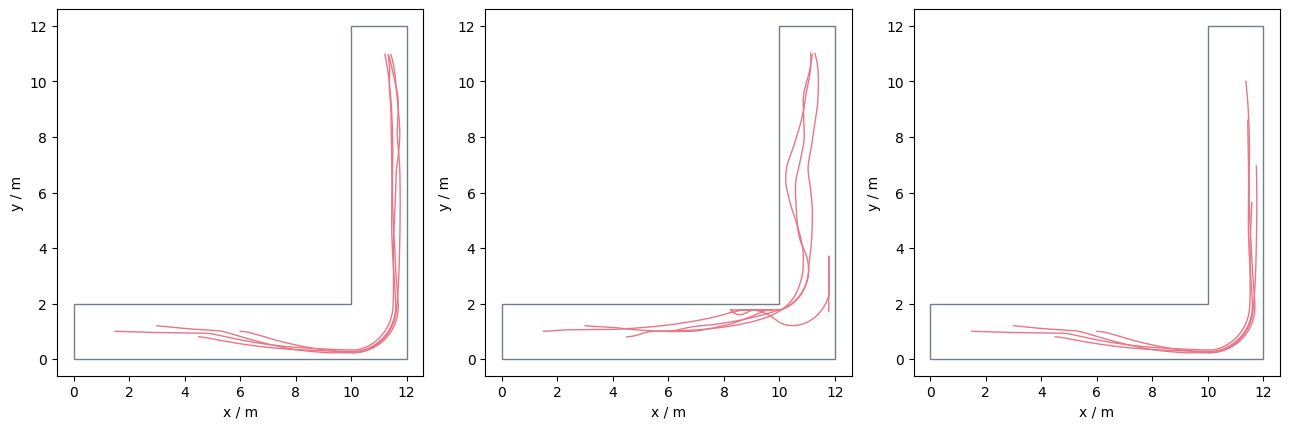

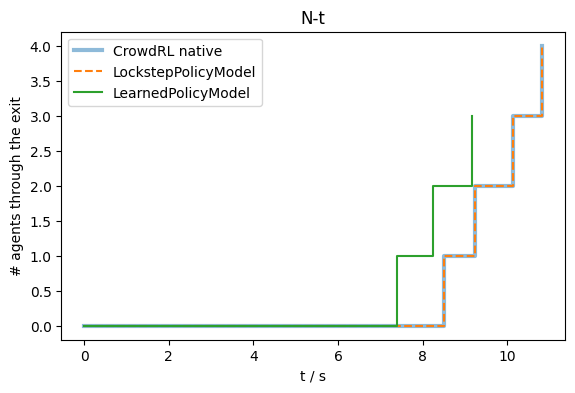

LearnedPolicyModel agent 0: deviation mean 2.762830 m, max 7.306180 m
LearnedPolicyModel agent 1: deviation mean 1.365030 m, max 2.178592 m
LearnedPolicyModel agent 2: deviation mean 1.573747 m, max 2.306581 m
LearnedPolicyModel agent 3: deviation mean 1.686352 m, max 2.201285 m
Lockstep           agent 0: deviation mean 0.000000 m, max 0.000000 m
Lockstep           agent 1: deviation mean 0.000000 m, max 0.000000 m
Lockstep           agent 2: deviation mean 0.000000 m, max 0.000000 m
Lockstep           agent 3: deviation mean 0.000000 m, max 0.000000 m


In [8]:
import matplotlib.pyplot as plt

interactive_traj, interactive_walkable = read_sqlite_file(interactive_file)
lockstep_traj, lockstep_walkable = read_sqlite_file(lockstep_file)

fig = plt.figure(figsize=(13, 4.6))
for panel, (title, source) in enumerate(
    [
        ("CrowdRL native (reference)", native_to_pedpy(native_traj)),
        ("LearnedPolicyModel (interactive)", interactive_traj),
        ("LockstepPolicyModel (byte-exact)", lockstep_traj),
    ],
    start=1,
):
    ax = fig.add_subplot(1, 3, panel, aspect="equal")
    ax.set_title(title, fontsize=10)
    pedpy.plot_trajectories(traj=source, axes=ax, walkable_area=pedpy.WalkableArea(CORNER_AREA))
plt.tight_layout()
plt.show()

# N-t: lockstep must sit exactly on the native curve.
frames = interactive_traj.data.groupby("id")["frame"].max()
interactive_exit_times = sorted(f / 25.0 for f in frames[frames < frames.max()])

fig, ax = plt.subplots(figsize=(6.5, 4))
for label, times, style in (
    ("CrowdRL native", sorted(s * 0.01 for s in native_exits.values()), {"linewidth": 3, "alpha": 0.5}),
    ("LockstepPolicyModel", sorted(s * 0.01 for s in lockstep_exits.values()), {"linestyle": "--"}),
    ("LearnedPolicyModel", interactive_exit_times, {}),
):
    ax.step([0.0] + list(times), range(len(times) + 1), where="post", label=label, **style)
ax.set_xlabel("t / s"); ax.set_ylabel("# agents through the exit"); ax.set_title("N-t")
ax.legend()
plt.show()

# Per-agent deviation vs the native reference (sampled at the 25 fps frames).
native_arr = np.array([[t.get(i, (np.nan, np.nan)) for i in range(len(CORNER_SPAWNS))]
                       for t in native_traj])
for name, traj_data in (("LearnedPolicyModel", interactive_traj), ("Lockstep", lockstep_traj)):
    by_id = {i: g.sort_values("frame")[["x", "y"]].to_numpy()
             for i, g in traj_data.data.groupby("id")}
    for idx, (jid, jt) in enumerate(sorted(by_id.items())):
        ref = native_arr[::4, idx, :]
        common = min(len(jt), len(ref))
        valid = ~np.isnan(ref[:common, 0])
        dev = np.linalg.norm(jt[:common][valid] - ref[:common][valid], axis=1)
        print(f"{name:18s} agent {idx}: deviation mean {dev.mean():.6f} m, max {dev.max():.6f} m")

In [9]:
# Replay: the interactive LearnedPolicyModel at trained dynamics. Note the
# diverging agent entering the wall-facing absorbing state in the corridor.
data, area = read_sqlite_file(interactive_file)
animate(data, area, every_nth_frame=5, radius=0.225, title_note="LearnedPolicyModel (interactive)")

In [10]:
# Replay: LockstepPolicyModel -- this animation IS the native CrowdRL run,
# byte for byte, rendered out of JuPedSim.
data, area = read_sqlite_file(lockstep_file)
animate(data, area, every_nth_frame=5, radius=0.225, title_note="LockstepPolicyModel (byte-exact)")

### What separates the two models -- and which to use

| | `LearnedPolicyModel` (interactive) | `LockstepPolicyModel` (validation) |
|---|---|---|
| Waypoint | JuPedSim router `next_target` (`path_deviation = 0`) | own navmesh funnel + true `path_deviation` (identical to training) |
| Stepping | per-agent callback, per-agent physics | one native batched step per iteration, rows served from cache |
| Removal | JuPedSim exit stage (lags 2 iterations) | native semantics inside the model (frozen rows) |
| Journeys / routing | any JuPedSim journey, re-routing, multi-stage | fixed final goals, single exit stages, bypasses the router |
| Dependencies | crowdrl-core + onnxruntime | additionally `crowdrl-core[geometry]` (`triangle`) for the navmesh |
| Cost | one obs + one inference per agent-step | + ~2 navmesh path queries per agent-step |
| Fidelity | route-level faithful, not bit-exact | **byte-identical** to the native run (machine-scoped) |

**Is Lockstep practical as a general JuPedSim operational model? No -- by
design.** It works inside JuPedSim, but it deliberately ignores what makes
JuPedSim JuPedSim: the router, journeys, stage transitions and dynamic
re-routing are all bypassed in favour of its own navmesh and removal
bookkeeping, it needs the full geometry and every exit polygon up front, and
it drags the `triangle` dependency back into deployment. It is a
**validation instrument**: IAS-7-style comparisons, regression baselines,
and any claim that "JuPedSim reproduces the CrowdRL result" should run
through it. `LearnedPolicyModel` is the JuPedSim-native citizen.

**What retraining would let `LearnedPolicyModel` be interpreted correctly?**
Close the two signal gaps at the source, so the policy expects exactly what
JuPedSim can supply:

1. **Train on router-like waypoints.** Randomise the waypoint source during
   training between the funnel apex and raw (non-inset, corner-hugging)
   portal points, including a few steps of switching lag -- the policy then
   tolerates the router's corner-targeting semantics natively (and the
   opt-in `waypoint_clearance` becomes unnecessary).
2. **Train without `path_deviation`** (a `no_p_dev` ablation, like
   `use_goal_direction=False` before it): deployment can never supply the
   true value, and this notebook's measurements show feeding 0.0 is not
   neutral (the corridor runs at +3..4 sigma). A policy trained with the
   signal absent has nothing to miss.
3. **Absorbing-state robustness**: penalise wall-facing zero-progress (the
   temporal features already expose it) so marginal states pivot out
   instead of freezing -- the 240 deg/s low-speed pivot is available and
   unused.
4. **Metadata schema v2**: embed the dynamics block
   (`desired_velocity_weight`, contact constants, dt) so deployment can
   never run the wrong physics silently.

With 1-3 trained in, the interactive adapter's inputs match training
semantics exactly and the remaining engine differences are the measured
sub-ULP float effects -- route-level transfer without a navmesh at
deployment, which is the production goal.